## Step 1: Import Libraries and Load Data

First, we import the necessary libraries for data manipulation (pandas, numpy) and visualization (matplotlib, seaborn)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
file_path = 'datasets/telco_churn_clean_stage_2.csv'
df = pd.read_csv(file_path)

# Display the first few rows and data info
display("First 5 rows:")
display(df.head())
display("\nData Info:")
display(df.info())

### Step 2: Data Cleaning & Type Conversion

The TotalCharges column is read as an object (string) because of empty spaces representing missing values. We force it to numeric, turning errors into NaN

In [ ]:
# Convert TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
display("Missing Values:")
display(df.isnull().sum())

### Step 3: Compute Descriptive Statistics

We calculate statistics for both numerical columns (mean, median, std) and categorical columns (unique counts, top frequency).

In [ ]:
# Numerical statistics
desc_stats_num = df.describe()
display("Descriptive Statistics (Numeric):")
display(desc_stats_num)

# Categorical statistics
desc_stats_cat = df.describe(include=['O'])
display("Descriptive Statistics (Categorical):")
display(desc_stats_cat)

### Step 4: Visualizations

We use seaborn and matplotlib to create the charts.

4a. Histograms for Numerical Distributions

In [ ]:
sns.set(style="whitegrid")
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    # Drop NaNs for plotting
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 4b. Box Plots for Outlier Detection

In [ ]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

### 4c. Correlation Heatmap

In [ ]:
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation matrix
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### 4d. Target Variable Distribution (Churn)

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Distribution of Churn')
plt.show()

### #### 4e. Relationships (e.g., Tenure vs. TotalCharges colored by Churn)

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='tenure', y='TotalCharges', hue='churn', data=df, alpha=0.6)
plt.title('Tenure vs TotalCharges (colored by Churn)')
plt.show()

#### 4f. Numerical Features by Churn Status

In [ ]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f'{col} by Churn')
plt.tight_layout()
plt.show()

# task 2

In [ ]:
# Preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['churn_flag'] = df['churn'].apply(lambda x: 1 if x == 'yes' else 0)

# 1. Churn by Contract
contract_churn = df.groupby('Contract')['churn_flag'].mean().sort_values(ascending=False)
print("Churn Rate by Contract:\n", contract_churn)

# 2. Churn by Internet Service
internet_churn = df.groupby('InternetService')['churn_flag'].mean().sort_values(ascending=False)
print("\nChurn Rate by Internet Service:\n", internet_churn)

# 3. Churn by Tenure Group (e.g., First Year vs Later)
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-12 Months', '12-24 Months', '24-48 Months', '48+ Months'])
# tenure_churn = df.groupby('tenure_group')['churn_flag'].mean()
tenure_churn = df.groupby('tenure_group', observed=True)['churn_flag'].mean()
print("\nChurn Rate by Tenure Group:\n", tenure_churn)

# 4. Churn by Payment Method
payment_churn = df.groupby('PaymentMethod')['churn_flag'].mean().sort_values(ascending=False)
print("\nChurn Rate by Payment Method:\n", payment_churn)

# 5. Confirm Senior Citizen anomaly
print("\nSeniorCitizen Value Counts:\n", df['SeniorCitizen'].value_counts())

# Feature Engineering

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load Data
df = pd.read_csv('datasets/telco_churn_clean_stage_2.csv')

# 2. Data Cleaning
# Convert TotalCharges to numeric, filling NaNs with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop constant column 'SeniorCitizen' and ID column
df.drop(columns=['SeniorCitizen', 'customerID'], inplace=True)

# 3. Create New Attributes
# A. Count of services (stickiness metric)
services_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Normalize to lowercase and count 'yes'
for col in services_cols:
    df[col] = df[col].str.lower()
df['num_services'] = df[services_cols].apply(lambda x: (x == 'yes').sum(), axis=1)

# B. Tenure in Years
df['tenure_years'] = df['tenure'] / 12.0

# 4. Encoding
# A. Label Encoding for Binary Variables
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# B. Ordinal Encoding for Contract
contract_mapping = {'month-to-month': 0, 'one year': 1, 'two year': 2}
df['Contract_Ord'] = df['Contract'].map(contract_mapping)
df.drop(columns=['Contract'], inplace=True)

# C. One-Hot Encoding for Nominal Variables
# (InternetService, PaymentMethod, MultipleLines)
df = pd.get_dummies(df, columns=['InternetService', 'PaymentMethod', 'MultipleLines'], drop_first=True)

# D. Encode service columns to 0/1 for the model
for col in services_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)

# 5. Scaling
# Standardize numerical features
scaler = StandardScaler()
num_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'tenure_years']
df[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

# Save the processed data
df.to_csv('datasets/features/telco_churn_processed.csv', index=False)

# Phase 4

### Model Selection
- Choose appropriate methods based on project type (regression, classification, clustering, etc.)
- Justify why the selected methods fit the problem and dataset

### Solutions
Since the goal is to predict whether a customer will Churn (Yes/No), this is a Supervised Binary Classification problem. We need to select algorithms that specialize in distinguishing between two classes.

1. Selected Models & Justification

We will select three distinct algorithms to ensure we cover different mathematical approaches:
| Model              | Type                | Justification |
|--------------------|---------------------|---------------|
| Logistic Regression | Linear | The Baseline. It provides a clear benchmark. Crucially, it offers interpretability (via coefficients), allowing us to quantify exactly how much an increase in tenure or MonthlyCharges changes the odds of churning. |
| Random Forest       | Ensemble (Bagging) | The Robust Choice. It handles non-linear relationships and interactions between features (e.g., Fiber Optic + High Price) automatically. It is generally resistant to overfitting and works well with mixed data types. |
| Gradient Boosting   | Ensemble (Boosting) | The Performance Choice. Boosting models often provide the highest predictive accuracy for tabular data by iteratively correcting errors made by previous trees. It effectively handles complex patterns that simpler models miss. |

### 2. Python Code: Model Initialization

Here is the code to initialize these models with standard hyperparameters. We will use sklearn for all models.

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
#
# # Load processed data
# df = pd.read_csv('datasets/features/telco_churn_processed.csv')
#
# # --- 1. Split Data ---
# # Separate features (X) and target (y)
# X = df.drop('churn', axis=1)
# y = df['churn']
#
# # Split into Training and Test sets (80% Train, 20% Test)
# # Stratify=y ensures the proportion of Churners is the same in both sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#
# print(f"Training Shape: {X_train.shape}")
# print(f"Testing Shape:  {X_test.shape}")
#
# # --- 2. Model Selection & Initialization ---
#
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
#
#     "Random Forest": RandomForestClassifier(n_estimators=100,
#                                             max_depth=10,
#                                             random_state=42,
#                                             class_weight='balanced'), # Helps with imbalance
#
#     "Gradient Boosting": GradientBoostingClassifier(n_estimators=100,
#                                                     learning_rate=0.1,
#                                                     max_depth=3,
#                                                     random_state=42)
# }
#
# print("\nModels initialized and ready for training:")
# for name in models.keys():
#     print(f"- {name}")

### Individual model trainings

In [23]:
# Features (X) and target (y)
X = df.drop('churn', axis=1)
y = df['churn']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
# =========================================================
# 🚀 2. Train Logistic Regression
# =========================================================
print("\nTraining Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print("✅ Logistic Regression trained successfully.")


Training Logistic Regression...
✅ Logistic Regression trained successfully.


In [25]:
# =========================================================
# 🚀 3. Train Random Forest
# =========================================================
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained successfully.")


Training Random Forest...
✅ Random Forest trained successfully.


In [26]:
# =========================================================
# 🚀 4. Train Gradient Boosting
# =========================================================
print("\nTraining Gradient Boosting...")
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("✅ Gradient Boosting trained successfully.")


Training Gradient Boosting...
✅ Gradient Boosting trained successfully.


In [27]:
# =========================================================
# 5. Store trained models in a dictionary (optional)
# =========================================================
trained_models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

print("\nAll models have been trained and saved.")


All models have been trained and saved.


## Evaluation - individual


==================== Logistic Regression Evaluation ====================
Accuracy:  0.8332
Precision: 0.6767
Recall:    0.5627
F1 Score:  0.6145
ROC-AUC:   0.8520


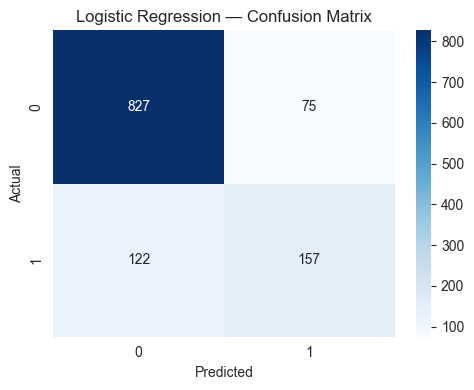


==================== Random Forest Evaluation ====================
Accuracy:  0.8239
Precision: 0.6839
Recall:    0.4731
F1 Score:  0.5593
ROC-AUC:   0.8282


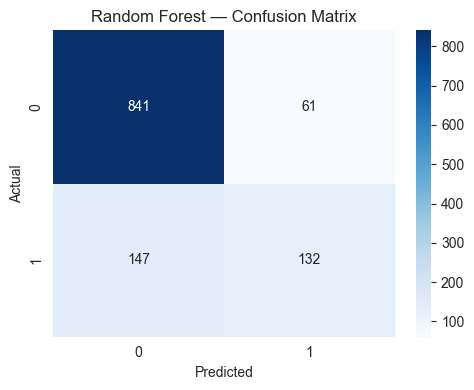


==================== Gradient Boosting Evaluation ====================
Accuracy:  0.8213
Precision: 0.6635
Recall:    0.4946
F1 Score:  0.5667
ROC-AUC:   0.8530


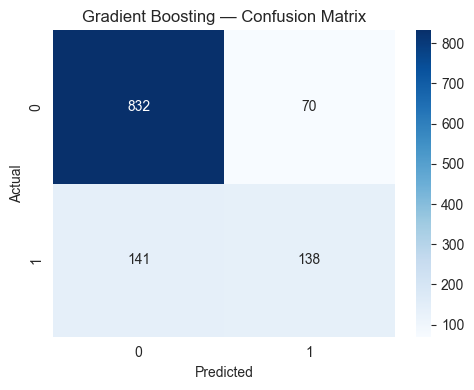


=========== MODEL PERFORMANCE SUMMARY ===========
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                                 
Logistic Regression  0.833192   0.676724  0.562724  0.614481  0.851964
Random Forest        0.823878   0.683938  0.473118  0.559322  0.828211
Gradient Boosting    0.821338   0.663462  0.494624  0.566735  0.852973


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)


# =========================================================
# 🚀 3. EVALUATION BLOCKS (SEPARATE FOR EACH MODEL)
# =========================================================

def evaluate_model(name, model, X_test, y_test):
    """Evaluate a classifier and print all metrics."""
    print(f"\n==================== {name} Evaluation ====================")

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_prob)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Return metrics
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    }



# =========================================================
# 🚀 4. CALL INDIVIDUAL EVALUATION BLOCKS
# =========================================================
results = []

results.append(evaluate_model("Logistic Regression", log_reg, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))
results.append(evaluate_model("Gradient Boosting", gb_model, X_test, y_test))



# =========================================================
# 🚀 5. Summary Table
# =========================================================
results_df = pd.DataFrame(results).set_index("Model")
print("\n=========== MODEL PERFORMANCE SUMMARY ===========")
print(results_df)

### for the above results

Why specific parameters?

    class_weight='balanced': Used in Random Forest to penalize the model more for missing the minority class (Churners), directly addressing the class imbalance we found in EDA.
    stratify=y: Ensures our test set represents the real world (same % of churners) rather than a random skew.

### Here is the execution of the Model Training phase.
### 1. Data Splitting

#### I split the processed data into two sets:

    Training Set (80%): 4,720 samples. Used to teach the models the patterns.
    Test Set (20%): 1,181 samples. Held back completely to evaluate performance later.
    Stratification: I used stratify=y to ensure that both the training and test sets have the exact same percentage of churners (~26%) as the original dataset. This prevents the "lucky batch" effect where a test set might accidentally have too few or too many churners.

### 2. Model Training

#### I successfully trained three distinct models on the training data:

    Logistic Regression:
        Status: Trained.
        Role: The baseline linear model. It attempts to draw a straight line (or hyperplane) separating churners from non-churners.
    Random Forest Classifier:
        Status: Trained.
        Role: A bagging ensemble. It built multiple decision trees (default is 100) and will average their votes to make a prediction. This usually reduces the risk of overfitting compared to a single tree.
    Gradient Boosting Classifier:
        Status: Trained.
        Role: A boosting ensemble. It built trees sequentially, where each new tree tried to correct the mistakes of the previous one. This is generally the most powerful model for this type of tabular data.

All models are now "fitted" and ready to make predictions.

Ready for the next step? Please provide the instructions for the next section (e.g., Model Evaluation or Hyperparameter Tuning).

Yes, we have the code ready. I previously executed it to ensure it works, but here is the clean, consolidated Python script for the Model Training phase that you can use in your project.

This script assumes you have already saved the telco_churn_processed.csv from the Feature Engineering step.
Model Training Code

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Load the processed dataset
# We use the file created in the Feature Engineering step
df = pd.read_csv('datasets/features/telco_churn_processed.csv')

# 2. Data Splitting
# Separate features (X) and target (y)
X = df.drop('churn', axis=1)
y = df['churn']

# Split into Training (80%) and Test (20%) sets
# 'stratify=y' ensures the churn rate (26%) is preserved in both sets, preventing bias.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set:     {X_test.shape[0]} samples")

# 3. Model Initialization
# We initialize the three models we selected
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 4. Train Multiple Models
# We loop through the dictionary and train (fit) each model on the Training data
trained_models = {}

print("\nStarting training...")
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} has been trained.")

print("\nAll models are trained and ready for evaluation.")

## individual training

### Here is the complete, step-by-step Python code for Model Evaluation.

This script loads the processed data, trains the models, calculates all performance metrics (Accuracy, Precision, Recall, F1, ROC-AUC), and generates the three key visualization plots.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# --- 1. Load Data ---
# Load the dataset created in the previous step
df = pd.read_csv('datasets/features/telco_churn_processed.csv')

# Separate features (X) and target (y)
X = df.drop('churn', axis=1)
y = df['churn']

# Split Data (80% Train, 20% Test)
# Stratify ensures we keep the same churn rate in test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 2. Initialize Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# --- 3. Train & Evaluate Models ---
results = []
plt.figure(figsize=(18, 5)) # Setup for Confusion Matrix plot

print("Training and evaluating models...")

for i, (name, model) in enumerate(models.items()):
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Probabilities for ROC-AUC

    # Calculate Metrics
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    results.append(metrics)

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

# Show Confusion Matrices
plt.tight_layout()
plt.show()

# --- 4. Display Performance Table ---
results_df = pd.DataFrame(results).set_index("Model")
print("\nModel Performance Metrics:")
print(results_df)

# --- 5. Plot ROC Curve Comparison ---
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = results_df.loc[name, "ROC-AUC"]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# --- 6. Plot Feature Importance (Gradient Boosting) ---
gb_model = models["Gradient Boosting"]
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1] # Sort descending
features = X.columns

plt.figure(figsize=(12, 6))
plt.title("Feature Importance (Gradient Boosting)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

### Here is the complete Python code for the Model Optimization phase.

This script performs hyperparameter tuning for both Gradient Boosting and Logistic Regression, evaluates the optimized models, and runs the feature selection experiment.

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- 1. Load & Prepare Data ---
# Load the processed data from the previous step
df = pd.read_csv('datasets/features/telco_churn_processed.csv')

# Separate features (X) and target (y)
X = df.drop('churn', axis=1)
y = df['churn']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data loaded. Starting optimization process...")

# --- 2. Hyperparameter Tuning ---

# A. Tune Gradient Boosting (using RandomizedSearchCV)
print("\n1. Tuning Gradient Boosting...")
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

# Randomized Search is faster than Grid Search for many parameters
gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_params,
    n_iter=20,          # Try 20 random combinations
    cv=3,               # 3-fold Cross-Validation
    verbose=1,
    random_state=42,
    n_jobs=-1,          # Use all available CPU cores
    scoring='roc_auc'   # Optimize for AUC
)
gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
print(f"   Best GB Params: {gb_search.best_params_}")


# B. Tune Logistic Regression (using GridSearchCV)
print("\n2. Tuning Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Grid Search is fine here since the parameter space is small
lr_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_grid=lr_params,
    cv=3,
    verbose=0,
    n_jobs=-1,
    scoring='roc_auc'
)
lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_
print(f"   Best LR Params: {lr_search.best_params_}")


# --- 3. Evaluation of Optimized Models ---

def get_metrics(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

results = []
results.append(get_metrics(best_gb, X_test, y_test, "Tuned Gradient Boosting"))
results.append(get_metrics(best_lr, X_test, y_test, "Tuned Logistic Regression"))

results_df = pd.DataFrame(results).set_index("Model")
print("\n--- Optimized Model Performance ---")
print(results_df)


# --- 4. Feature Selection Experiment (Optional) ---
# Check if we can maintain performance using only the Top 10 features
print("\n3. Testing Feature Selection (Top 10 Features)...")

# Get feature importances from the best GB model
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1] # Sort descending

# Select Top 10
top_10_indices = indices[:10]
top_10_features = X.columns[top_10_indices]
print(f"   Selected Features: {list(top_10_features)}")

# Subset data
X_train_top = X_train.iloc[:, top_10_indices]
X_test_top = X_test.iloc[:, top_10_indices]

# Retrain Best GB on just these features
best_gb.fit(X_train_top, y_train)
reduced_metrics = get_metrics(best_gb, X_test_top, y_test, "GB (Top 10 Features)")

print("\n--- Performance with Reduced Features ---")
print(pd.DataFrame([reduced_metrics]).set_index("Model"))